# Assignment 4 - Neuroscience

## Setup and Required Libraries

In [1]:
# run this cell in case of a problem with the imports 
# %pip install pandas numpy torch torchaudio h5py soundfile spicy umap-learn seaborn

In [2]:
import numpy as np
import torch
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, kendalltau, ttest_ind, ttest_ind
from torch.utils.data import DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import umap

from core import SantoroDataset, MODEL_CLASSES, extract_activations, load_yamnet_activations
from config import CHECKPOINT_DIR, NUM_CLASSES, BATCH_SIZE
from util import mean_and_ci

## Toolbox

In [3]:
def compute_rdm(patterns: np.ndarray, metric: str = "euclidean") -> np.ndarray:
    """Compute the Euclidean-distance RDM for a set of representational patterns."""

    # Ensure we have np array and not torch tensor
    patterns = np.asarray(patterns)

    # Flatten into 1D data
    patterns = patterns.reshape(patterns.shape[0], -1)

    # Compute pairwise euclidean distances
    eucl_distances = pdist(patterns, metric=metric)

    # Convert distances into symmetric matrix
    return squareform(eucl_distances)

def build_model_rdms(model_activations: dict, metric: str = "euclidean") -> dict:
    """Build RDMs for every model, run, and layer using the chosen distance metric."""

    model_rdms = {}

    # Go through each model
    for model_name, runs in model_activations.items():

        model_rdms[model_name] = []


        for run_activations in runs:

            rdms = {}

            # Go through each trainable layer
            for layer_name, activations in run_activations.items():
                rdms[layer_name] = compute_rdm(activations, metric=metric)
                
            model_rdms[model_name].append(rdms)

    return model_rdms


def upper_triangle(rdm: np.ndarray) -> np.ndarray:
    """Extract the off-diagonal upper-triangular entries of an RDM as a 1D vector."""

    # Get indices of the upper triangular values
    # We use k = 1 not to include 0s at the main diagonal
    row_indices, col_indices = np.triu_indices(n=rdm.shape[0], k=1)

    return rdm[row_indices, col_indices]


def compare_rdms(rdm_a: np.ndarray, rdm_b: np.ndarray, method: str = "pearson") -> float:
    """Compare two RDMs via Pearson correlation of their upper-triangular entries."""

    # Get upper triangular values
    up_values_a = upper_triangle(rdm_a)
    up_values_b = upper_triangle(rdm_b)

    if method == "pearson":
        centered_a = up_values_a - np.mean(up_values_a)
        centered_b = up_values_b - np.mean(up_values_b)

        numerator = np.sum(centered_a * centered_b)
        denominator = np.sqrt(np.sum(centered_a ** 2) * np.sum(centered_b ** 2))

        if denominator == 0:
            return 0.0
        return float(numerator / denominator)
    elif method == "spearman":
        r, _ = spearmanr(up_values_a, up_values_b)
        return 0.0 if np.isnan(r) else float(r)
    elif method == "kendall":
        tau, _ = kendalltau(up_values_a, up_values_b)
        return 0.0 if np.isnan(tau) else float(tau)
    else:
        raise ValueError(f"Unknown comparison method: {method}")


def compute_layer_alignments(model_rdms: dict, target_rdm: np.ndarray, method: str = "pearson") -> dict:
    """Compute mean and 95% CI RSA correlation with target_rdm for each layer across runs."""

    alignments = {}

    # Go through each model
    for model_name, runs in model_rdms.items():

        alignments[model_name] = {}

        # Get all layers
        layer_names = list(runs[0].keys())

        # Go through each layer
        for layer_name in layer_names:

            scores = []

            # Go through each run
            for run in runs:
                scores.append(compare_rdms(target_rdm, run[layer_name], method=method))

            # Convert list to numpy array for mean_and_ci
            mean, ci = mean_and_ci(np.array(scores))

            # Store scores across runs per layer
            alignments[model_name][layer_name] = {
                "mean": float(mean),
                "ci": float(ci),
                "scores": scores,
            }

    return alignments

def plot_embeddings(representations_dict, categories, method="tsne"):
    """Computes and plots 2D embeddings with a unique color + marker per category."""
    categories = np.asarray(categories)
    unique_categories = np.unique(categories)

    # Generate unique RGB colors
    palette = sns.color_palette("gist_ncar", len(unique_categories))
    cat_to_color = {cat: palette[i] for i, cat in enumerate(unique_categories)}

    # Cycle through 5 marker shapes so adjacent colors are easy to tell apart
    markers = ["o", "s", "^", "D", "P"]
    cat_to_marker = {}
    for i, category in enumerate(unique_categories):
        cat_to_marker[category] = markers[i % len(markers)]

    # Create 3 x 4 grid - 12 plots
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    for ax, (title, data) in zip(axes, representations_dict.items()):
        # Flatten data
        flat_data = np.asarray(data).reshape(data.shape[0], -1)

        # Choose method
        if method.lower() == "tsne":
            reducer = TSNE(n_components=2, perplexity=30, random_state=42)
        elif method.lower() == "umap":
            reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
        else:
            raise ValueError("Method must be 'tsne' or 'umap'")

        coords_2d = reducer.fit_transform(flat_data)

        for category in unique_categories:
            mask = categories == category
            ax.scatter(
                coords_2d[mask, 0],
                coords_2d[mask, 1],
                color=cat_to_color[category],
                marker=cat_to_marker[category],
                label=category,
                alpha=0.85,
                s=28,
                edgecolors="none",
            )

        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xticks([])
        ax.set_yticks([])

    # Split legend into 3 columns on the right
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        ncol=3,
        fontsize=8.5,
        title="Categories",
    )
    plt.suptitle(f"2D Manifold Visualizations via {method.upper()}", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

## Part I: RSA for Model to Brain Analysis

### 1. Constructing RDMs

In [4]:
# STG brain data
santoro_dataset = SantoroDataset()

# Store already existing reactions
rdm_stg = compute_rdm(santoro_dataset.brain_responses.numpy())

# 288 sounds in dataset
rdm_stg.shape

(288, 288)

In [5]:
print(MODEL_CLASSES)

{'waveform': <class 'models.WaveformModel'>, 'uninspired': <class 'models.UninspiredModel'>, 'inspired': <class 'models.InspiredModel'>}


In [6]:
# Untrained Models RDMs

# Traditional loader hoping that you have GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
santoro_loader = DataLoader(santoro_dataset, batch_size=32, shuffle=False)

untrained_rdms = {}

# Go through each model
for model_name, model_cls in MODEL_CLASSES.items():

    # Load the model
    model = model_cls(num_classes=NUM_CLASSES).to(device)

    # Extract layers' activations
    layer_activations = extract_activations(santoro_loader, model)

    untrained_rdms[model_name] = {}

    # Go through each trainable layer
    for layer_name, activations in layer_activations.items():
        untrained_rdms[model_name][layer_name] = compute_rdm(activations.numpy())

In [7]:
# Trained Models RDMs

trained_rdms = {}

# Go through each model
for model_name, model_cls in MODEL_CLASSES.items():

    trained_rdms[model_name] = []

    # Scrap through folder to find checkpoints
    files = sorted(Path(CHECKPOINT_DIR).glob(f"{model_name}_run*_best.pt"))

    for path in files:

        # Load the model
        model = model_cls(num_classes=NUM_CLASSES).to(device)

        # Load weights
        state_dict = torch.load(path, map_location=device, weights_only=True)

        # Add weights to the model
        model.load_state_dict(state_dict)

        # Extract layers' activations
        layer_activations = extract_activations(santoro_loader, model)

        rdms = {}
        # Go through each trainable layer
        for layer_name, activations in layer_activations.items():
            rdms[layer_name] = compute_rdm(activations.numpy())
        
        trained_rdms[model_name].append(rdms)

In [8]:
# Pretrained yamnet model

yamnet_activations = load_yamnet_activations()

yamnet_rdms = {}

# Go through each layer
for layer_name, activations in yamnet_activations.items():
    yamnet_rdms[layer_name] = compute_rdm(activations)

### 2. Comparing the models to the brain data

The major analysis will be done based on standard RSA metrics, and later we will make comparison of metrics in order to see if the conclusions align or we need extra analysis 

#### Analysis and Answering Questions Based On Euclidian Distances and Pearson Correlation

In [9]:
# Run each untrained model 5 times to diminish potential noise

n_runs = 5
untrained_rdms = {}

# Go through each model
for model_name, model_cls in MODEL_CLASSES.items():

    untrained_rdms[model_name] = []

    for i in range(n_runs):

        # Load the model with new random weights
        model = model_cls(num_classes=NUM_CLASSES).to(device)

        # Extract layers' activations
        layer_activations = extract_activations(santoro_loader, model)

        rdms = {}
        # Go through each trainable layer
        for layer_name, activations in layer_activations.items():
            rdms[layer_name] = compute_rdm(activations.numpy())

        untrained_rdms[model_name].append(rdms)

In [10]:
# Compute alignments
untrained_alignments = compute_layer_alignments(untrained_rdms, rdm_stg)

trained_alignments = compute_layer_alignments(trained_rdms, rdm_stg)

# For yamnet we have only 1 run, so compare directly rdms
yamnet_alignments = {}
for layer_name, rdm in yamnet_rdms.items():
    yamnet_alignments[layer_name] = compare_rdms(rdm_stg, rdm)

In [11]:
# Compare trained and untrained across layers
for model_name in MODEL_CLASSES:
    print(f"\n{model_name.upper()}:\t(Mean ± 95% CI)")
    for layer in untrained_alignments[model_name]:
        u = untrained_alignments[model_name][layer]
        t = trained_alignments[model_name][layer]
        print(f"\t{layer:15s}\t| Untrained: {u['mean']:.4f} ± {u['ci']:.4f}\t| Trained: {t['mean']:.4f} ± {t['ci']:.4f}")

# Check yamnet
print("\nYAMNET:")
for layer, score in yamnet_alignments.items():
    print(f"\t{layer:15s}\t| Pretrained: {score:.4f}")


WAVEFORM:	(Mean ± 95% CI)
	hidden_layers.0	| Untrained: -0.0203 ± 0.0048	| Trained: -0.0786 ± 0.0153
	hidden_layers.1	| Untrained: -0.0212 ± 0.0042	| Trained: -0.0405 ± 0.0089
	hidden_layers.2	| Untrained: -0.0231 ± 0.0117	| Trained: -0.0277 ± 0.0095
	hidden_layers.3	| Untrained: -0.0125 ± 0.0113	| Trained: -0.0240 ± 0.0124
	hidden_layers.4	| Untrained: -0.0113 ± 0.0166	| Trained: -0.0104 ± 0.0135
	classifier     	| Untrained: -0.0203 ± 0.0166	| Trained: 0.0145 ± 0.0170

UNINSPIRED:	(Mean ± 95% CI)
	conv_layers.0  	| Untrained: 0.0271 ± 0.0128	| Trained: 0.0609 ± 0.0037
	conv_layers.1  	| Untrained: 0.0507 ± 0.0216	| Trained: 0.1009 ± 0.0093
	conv_layers.2  	| Untrained: 0.0753 ± 0.0247	| Trained: 0.0949 ± 0.0099
	fc_layers.0    	| Untrained: 0.0496 ± 0.0030	| Trained: -0.0010 ± 0.0101
	fc_layers.1    	| Untrained: 0.0470 ± 0.0017	| Trained: -0.0291 ± 0.0079
	classifier     	| Untrained: 0.0453 ± 0.0068	| Trained: -0.0369 ± 0.0077

INSPIRED:	(Mean ± 95% CI)
	conv_layers.0  	| Untraine

In [12]:
# Statistical Testing
print("Untrained vs Trained comparison of peak layers using t-test:")
for model_name in MODEL_CLASSES:
    best_layer = max(trained_alignments[model_name], key=lambda l: trained_alignments[model_name][l]["mean"])
    u_scores = untrained_alignments[model_name][best_layer]["scores"]
    t_scores = trained_alignments[model_name][best_layer]["scores"]

    t_stat, p_val = ttest_ind(t_scores, u_scores, equal_var=False)
    print(f"\t{model_name:10s} ({best_layer:15s} layer)\t| t = {t_stat:6.2f}, p = {p_val:.4e}")

print("\nCompare trained architectures among peak layers using t-test")
comparisons = [
    ("inspired", "uninspired"),
    ("inspired", "waveform"),
    ("uninspired", "waveform"),
]
for model1, model2 in comparisons:
    layer_best_model1 = max(trained_alignments[model1], key=lambda l: trained_alignments[model1][l]["mean"])
    layer_best_model2 = max(trained_alignments[model2], key=lambda l: trained_alignments[model2][l]["mean"])

    scores_1 = trained_alignments[model1][layer_best_model1]["scores"]
    scores_2 = trained_alignments[model2][layer_best_model2]["scores"]

    t_stat, p_val = ttest_ind(scores_1, scores_2, equal_var=False)
    print(f"\t{model1:10s} vs. {model2:10s}\t| t = {t_stat:6.2f}, p = {p_val:.4e}")

Untrained vs Trained comparison of peak layers using t-test:
	waveform   (classifier      layer)	| t =   2.87, p = 2.0796e-02
	uninspired (conv_layers.1   layer)	| t =   4.17, p = 7.2505e-03
	inspired   (conv_layers.1   layer)	| t =   5.44, p = 2.8452e-03

Compare trained architectures among peak layers using t-test
	inspired   vs. uninspired	| t =   2.04, p = 7.6896e-02
	inspired   vs. waveform  	| t =  10.42, p = 7.9963e-05
	uninspired vs. waveform  	| t =   8.72, p = 1.0392e-04


First we can answer the questions just by looking at the numbers.

1. Effect of Training
For both uninspired and inspired models the training at convolutional layer significantly increases the brain alignment. Moreover, the standard deviation is lower, meaning that across trained runs the variation was smaller and all models showed high results. However, at later layers we can see significant decrease of alignment among trained models, going even lower than the untrained models. One of the explanations of this case can be overfitting. By fitting too much on ESC-50 classes, models cannot work properly on different, Santoro STG dataset.
Waveform architecture is in general bad approach for this task because of which even training cannot help. Standard deviation is also high, so we can conclude the model is just not capable of actually learning anything meaningful because of its architecture.
**TODO: describe why Uninspired beats Inspired before training, but Inspired wins after training**
2. Effect of Architectural Choices
As discussed above, Waveform model totally fails to exctract meaningful acoustic features and therefore fails the brain alignment
Moving to spectogram input and convolutions helped Uninspired model to be significantly better than Waveform model even being untrained. 
The Inspired model still beats at all layers uninspired model. The reason for that is the use of ReLU6 which is more efficient and biologically plausible as same as neurons cannot fire negatively, ReLU also has lower bound on 0.
YAMNet, being a larger pre-trained audio event classification model, aligns the best with the STG data. We can see the similar trend of degradation of the latest layers of YAMNet as we saw for Inspired and Uninspired models. Meanwhile, comparing just the best layers we can see that the difference in alignment is not that big, so potentially we can use the simplier Inspired model reaching almost equal results. **TODO: explain why**
3. Alignment Across Layer Depth
For all models there is initial rise of metrics and then almost immediate significant drop. **TODO: explain why**

##### Part C. Evaluating depths

Not necesssarily the last layer is the best and most aligned with brain results. Therefore, we first do evaluation of layers, so that later part A comparison of models will be fairly done on the best layers at their peak results

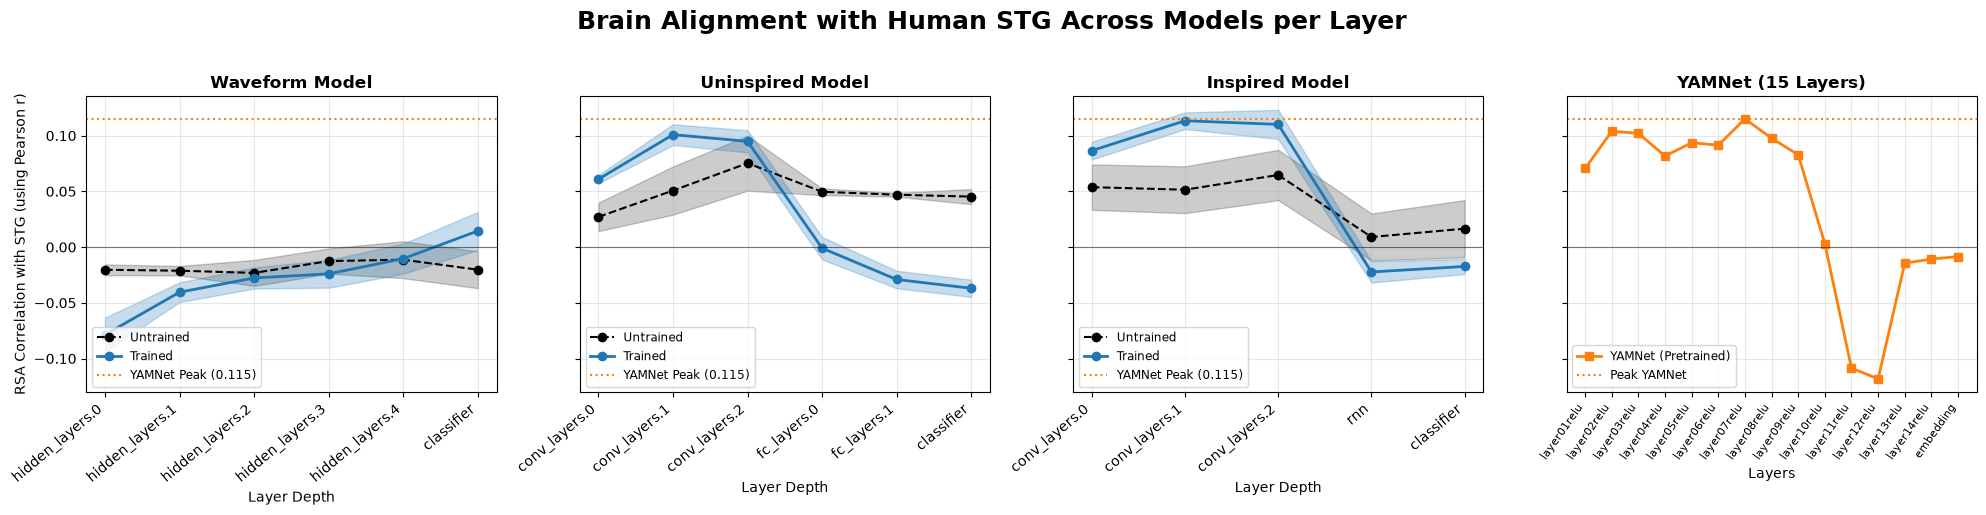

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
yamnet_peak = max(yamnet_alignments.values())

for ax, model_name in zip(axes[:3], MODEL_CLASSES.keys()):
    layers = list(untrained_alignments[model_name].keys())
    x = np.arange(len(layers))

    # Untrained mean & ci
    u_mean = np.array([untrained_alignments[model_name][l]["mean"] for l in layers])
    u_ci = np.array([untrained_alignments[model_name][l]["ci"] for l in layers])

    # Trained mean & ci
    t_mean = np.array([trained_alignments[model_name][l]["mean"] for l in layers])
    t_ci = np.array([trained_alignments[model_name][l]["ci"] for l in layers])

    # Plot Untrained
    ax.plot(x, u_mean, marker="o", linestyle="--", color="black", label="Untrained")
    # Add std visualization
    ax.fill_between(x, u_mean - u_ci, u_mean + u_ci, color="black", alpha=0.2)

    # Plot Trained
    ax.plot(x, t_mean, marker="o", linewidth=2, color="tab:blue", label="Trained")
    # Add std visualization
    ax.fill_between(x, t_mean - t_ci, t_mean + t_ci, color="tab:blue", alpha=0.25)

    # Reference lines (strongest yamnet)
    ax.axhline(yamnet_peak, color="tab:orange", linestyle=":", linewidth=1.5, label=f"YAMNet Peak ({yamnet_peak:.3f})")

    # Zero line
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)

    ax.set_title(f"{model_name.capitalize()} Model", fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(layers, rotation=40, ha="right")
    ax.set_xlabel("Layer Depth")
    ax.grid(alpha=0.3)
    ax.legend(loc="lower left", fontsize=8.5)

# Yamnet across all 15 layers
yam_layers = list(yamnet_alignments.keys())
yam_scores = list(yamnet_alignments.values())
x_yam = np.arange(len(yam_layers))

axes[3].plot(x_yam, yam_scores, marker="s", linewidth=2, color="tab:orange", label="YAMNet (Pretrained)")
axes[3].axhline(yamnet_peak, color="tab:orange", linestyle=":", linewidth=1.5, label=f"Peak YAMNet")
axes[3].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[3].set_title("YAMNet (15 Layers)", fontsize=12, fontweight="bold")
axes[3].set_xticks(x_yam)
axes[3].set_xticklabels(yam_layers, rotation=55, ha="right", fontsize=8)
axes[3].set_xlabel("Layers")
axes[3].grid(alpha=0.3)
axes[3].legend(loc="lower left", fontsize=8.5)
axes[0].set_ylabel("RSA Correlation with STG (using Pearson r)")

plt.suptitle("Brain Alignment with Human STG Across Models per Layer", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

##### Part A. Compare Trained and Untrained Models

Since we already had a first look comparing layers in part C, this time we compare peak alignment across models

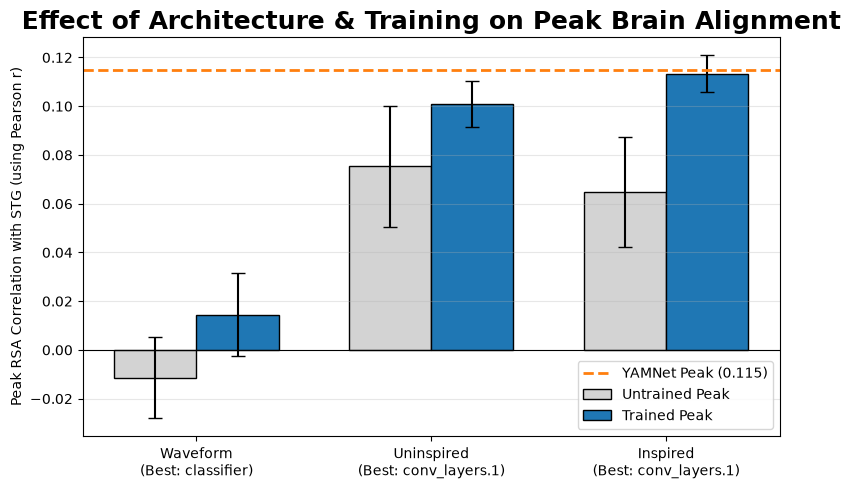

In [14]:
model_names = list(MODEL_CLASSES.keys())
x = np.arange(len(model_names))
width = 0.35

# Find the best layer (with highest mean) for each model in untrained and trained modes
u_peaks, u_cis, u_best_layers = [], [], []
t_peaks, t_cis, t_best_layers = [], [], []

for m in model_names:
    best_u_layer = max(untrained_alignments[m], key=lambda l: untrained_alignments[m][l]["mean"])
    u_peaks.append(untrained_alignments[m][best_u_layer]["mean"])
    u_cis.append(untrained_alignments[m][best_u_layer]["ci"])
    u_best_layers.append(best_u_layer)

    best_t_layer = max(trained_alignments[m], key=lambda l: trained_alignments[m][l]["mean"])
    t_peaks.append(trained_alignments[m][best_t_layer]["mean"])
    t_cis.append(trained_alignments[m][best_t_layer]["ci"])
    t_best_layers.append(best_t_layer)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width / 2, u_peaks, width, yerr=u_cis, capsize=5, color="lightgray", edgecolor="black", label="Untrained Peak")
ax.bar(x + width / 2, t_peaks, width, yerr=t_cis, capsize=5, color="tab:blue", edgecolor="black", label="Trained Peak")

# YAMNet Peak Reference Line
ax.axhline(yamnet_peak, color="tab:orange", linestyle="--", linewidth=2, label=f"YAMNet Peak ({yamnet_peak:.3f})")
ax.axhline(0, color="black", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f"{m.capitalize()}\n(Best: {l})" for m, l in zip(model_names, t_best_layers)])
ax.set_ylabel("Peak RSA Correlation with STG (using Pearson r)")
ax.set_title("Effect of Architecture & Training on Peak Brain Alignment", fontsize=18, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

##### Part B. Effect of architectural choices on brain alignment

TODO: maybe add some text, don't think we need code

#### RSA Metrics Comparison 

In [15]:
# Save actual activations, not direct RDMs

# Brain responses
stg_patterns = santoro_dataset.brain_responses.numpy()

# Untrained Models (5 runs per model)
n_runs = 5
untrained_activations = {}

# Go through each model
for model_name, model_cls in MODEL_CLASSES.items():

    untrained_activations[model_name] = []

    for i in range(n_runs):

        # Load the model
        model = model_cls(num_classes=NUM_CLASSES).to(device)

        # Extract layers' activations
        layer_activations = extract_activations(santoro_loader, model)

        # Convert tensors to numpy
        run_acts = {}
        for layer_name, acts in layer_activations.items():
            run_acts[layer_name] = acts.numpy()

        untrained_activations[model_name].append(run_acts)

# Trained Models
trained_activations = {}

# Go through each model
for model_name, model_cls in MODEL_CLASSES.items():
    
    trained_activations[model_name] = []

    # Scrap through folder to find checkpoints
    files = sorted(Path(CHECKPOINT_DIR).glob(f"{model_name}_run*_best.pt"))

    for path in files:

        # Load the model
        model = model_cls(num_classes=NUM_CLASSES).to(device)

        # Load weights
        state_dict = torch.load(path, map_location=device, weights_only=True)

        # Add weights to the model
        model.load_state_dict(state_dict)

        # Extract layers' activations
        layer_activations = extract_activations(santoro_loader, model)

        # Convert tensors to numpy
        run_acts = {}
        for layer_name, acts in layer_activations.items():
            run_acts[layer_name] = acts.numpy()

        trained_activations[model_name].append(run_acts)

# Pretrained yamnet model
yamnet_activations = load_yamnet_activations()

Compare distance metrics: euclidian vs correlation and comparison methods: pearson vs spearman

In [21]:
distance_metrics = ["euclidean", "correlation"]
comparison_methods = ["pearson", "spearman"]

# Store results in format of metric_results[(metric, method)]
metric_results = {}

# Go for distance metric
for metric in distance_metrics:

    # Build RDMs for distance metric based on stored activations

    # Brain responses
    rdm_stg_current = compute_rdm(stg_patterns, metric=metric)

    # Get RMDs for all untrained models: layers and runs
    untrained_rdms_current = build_model_rdms(untrained_activations, metric=metric)

    # Get RMDs for all trained models: layers and runs
    trained_rdms_current = build_model_rdms(trained_activations, metric=metric)

    # Specifically for YAMNet, for all layers
    yamnet_rdms_current = {}
    for layer_name, acts in yamnet_activations.items():
        yamnet_rdms_current[layer_name] = compute_rdm(acts, metric=metric)

    # Go for comparison metric
    for method in comparison_methods:
        # Compare RDMs using specific comparison method

        # Untrained Models
        untrained_align_current = compute_layer_alignments(untrained_rdms_current, rdm_stg_current, method=method)

        # Trained models
        trained_align_current = compute_layer_alignments(trained_rdms_current, rdm_stg_current, method=method)

        # Specifically for YAMNet, for all layers
        yamnet_align_current = {}
        for layer_name, rdm in yamnet_rdms_current.items():
            yamnet_align_current[layer_name] = compare_rdms(rdm_stg_current, rdm, method=method)

        # Save all results of metric, method combination
        metric_results[(metric, method)] = {
            "untrained": untrained_align_current,
            "trained": trained_align_current,
            "yamnet": yamnet_align_current,
        }

        # Get summary of peak layers for specific distance, comparison methods
        print(f"RDM Distance: {metric.upper()}\t| Comparison: {method.upper()}:")
        for model_name in MODEL_CLASSES:
            u_dict = untrained_align_current[model_name]
            t_dict = trained_align_current[model_name]

            best_u_layer = max(u_dict, key=lambda l: u_dict[l]["mean"])
            best_t_layer = max(t_dict, key=lambda l: t_dict[l]["mean"])

            u_best_result = u_dict[best_u_layer]
            t_best_result = t_dict[best_t_layer]

            print(f"{model_name:10s}\t| "
                f"Untrained ({best_u_layer:13s} layer): {u_best_result['mean']:7.4f} ± {u_best_result['ci']:.4f}\t| "
                f"Trained ({best_t_layer:13s} layer): {t_best_result['mean']:7.4f} ± {t_best_result['ci']:.4f}"
            )

        # Specifically extract YAMNet
        best_yam_layer = max(yamnet_align_current, key=yamnet_align_current.get)
        print(f"{'yamnet':10s}\t| Pretrained ({best_yam_layer:13s} layer): {yamnet_align_current[best_yam_layer]:7.4f}")
        print()

RDM Distance: EUCLIDEAN	| Comparison: PEARSON:
waveform  	| Untrained (classifier    layer):  0.0004 ± 0.0299	| Trained (classifier    layer):  0.0145 ± 0.0170
uninspired	| Untrained (conv_layers.2 layer):  0.0786 ± 0.0179	| Trained (conv_layers.1 layer):  0.1009 ± 0.0093
inspired  	| Untrained (conv_layers.2 layer):  0.0775 ± 0.0220	| Trained (conv_layers.1 layer):  0.1134 ± 0.0075
yamnet    	| Pretrained (layer07relu   layer):  0.1151

RDM Distance: EUCLIDEAN	| Comparison: SPEARMAN:
waveform  	| Untrained (hidden_layers.2 layer):  0.0140 ± 0.0192	| Trained (classifier    layer):  0.0114 ± 0.0126
uninspired	| Untrained (conv_layers.2 layer):  0.1005 ± 0.0163	| Trained (conv_layers.1 layer):  0.1079 ± 0.0093
inspired  	| Untrained (conv_layers.2 layer):  0.0864 ± 0.0258	| Trained (conv_layers.2 layer):  0.1221 ± 0.0176
yamnet    	| Pretrained (layer07relu   layer):  0.1218

RDM Distance: CORRELATION	| Comparison: PEARSON:
waveform  	| Untrained (classifier    layer): -0.0289 ± 0.0208	|

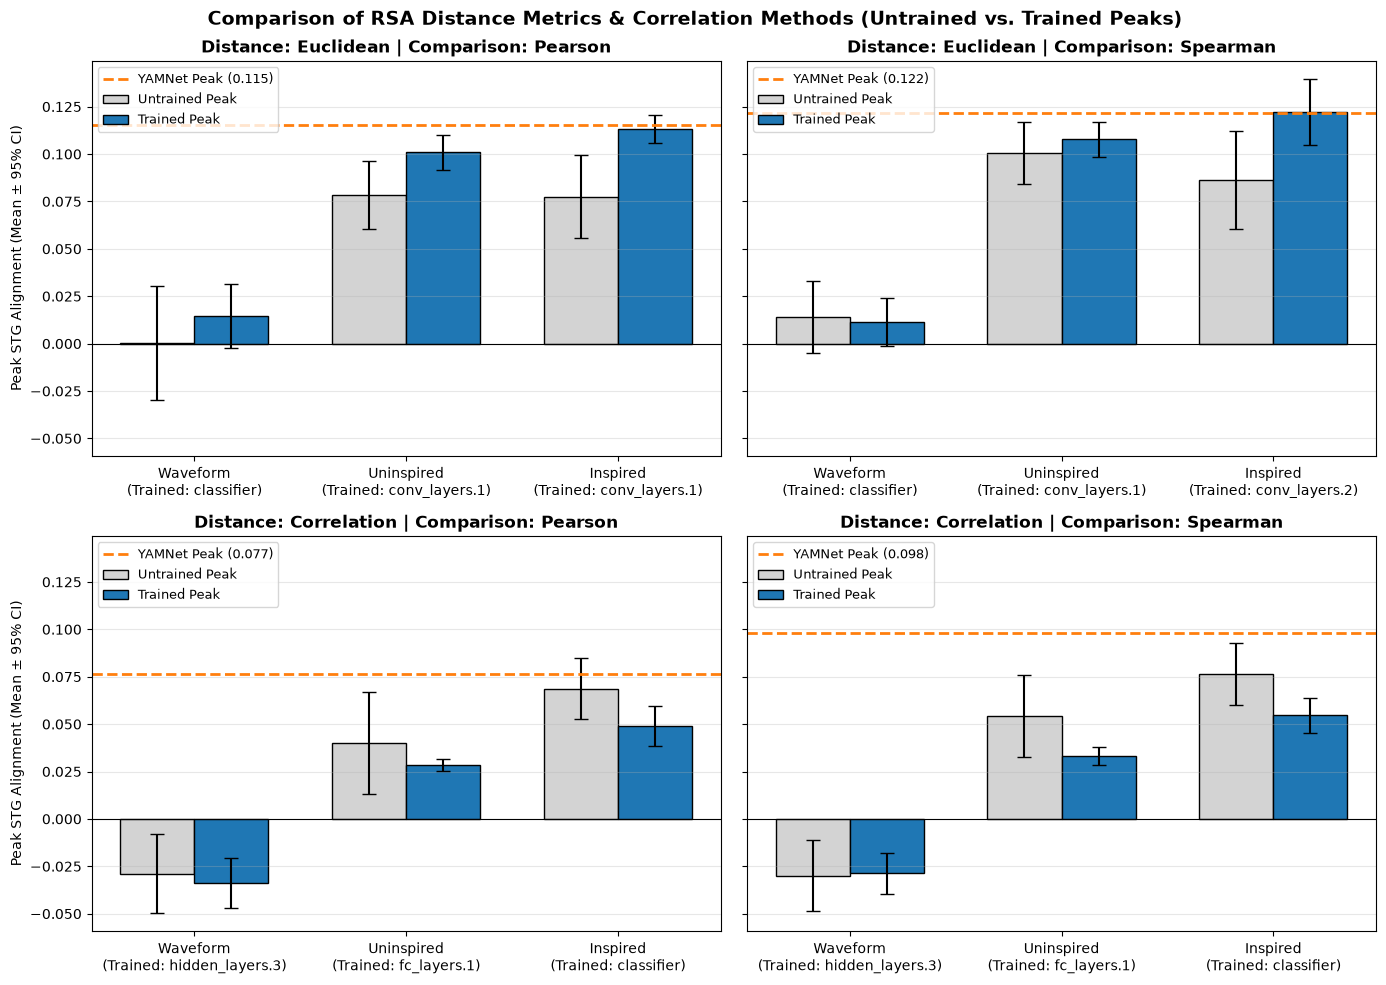

In [22]:
# Visualize 4 cases
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
model_names = list(MODEL_CLASSES.keys())
x = np.arange(len(model_names))
width = 0.35

for row_idx, metric in enumerate(distance_metrics):
    for col_idx, method in enumerate(comparison_methods):
        ax = axes[row_idx, col_idx]
        res_curr = metric_results[(metric, method)]

        u_means, u_cis = [], []
        t_means, t_cis = [], []
        t_best_layers = []

        # Extract peak untrained and trained scores for each model
        for m in model_names:
            u_dict = res_curr["untrained"][m]
            t_dict = res_curr["trained"][m]

            best_u = max(u_dict, key=lambda l: u_dict[l]["mean"])
            best_t = max(t_dict, key=lambda l: t_dict[l]["mean"])

            u_means.append(u_dict[best_u]["mean"])
            u_cis.append(u_dict[best_u]["ci"])

            t_means.append(t_dict[best_t]["mean"])
            t_cis.append(t_dict[best_t]["ci"])
            t_best_layers.append(best_t)

        # Extract YAMNet peak for this metric combination
        yam_peak = max(res_curr["yamnet"].values())
        yam_best_layer = max(res_curr["yamnet"], key=res_curr["yamnet"].get)

        # Plot Untrained vs. Trained bars with 95% CI error bars
        ax.bar(
            x - width / 2,
            u_means,
            width,
            yerr=u_cis,
            capsize=5,
            color="lightgray",
            edgecolor="black",
            label="Untrained Peak",
        )
        ax.bar(
            x + width / 2,
            t_means,
            width,
            yerr=t_cis,
            capsize=5,
            color="tab:blue",
            edgecolor="black",
            label="Trained Peak",
        )

        # Plot YAMNet benchmark line
        ax.axhline(
            yam_peak,
            color="tab:orange",
            linestyle="--",
            linewidth=2,
            label=f"YAMNet Peak ({yam_peak:.3f})",
        )
        ax.axhline(0, color="black", linewidth=0.8)

        ax.set_title(
            f"Distance: {metric.capitalize()} | Comparison: {method.capitalize()}",
            fontsize=12,
            fontweight="bold",
        )
        ax.set_xticks(x)
        ax.set_xticklabels([f"{m.capitalize()}\n(Trained: {l})" for m, l in zip(model_names, t_best_layers)])
        ax.grid(axis="y", alpha=0.3)
        ax.legend(loc="lower right" if yam_peak < 0.05 else "upper left", fontsize=9)

    axes[row_idx, 0].set_ylabel("Peak STG Alignment (Mean ± 95% CI)")

plt.suptitle(
    "Comparison of RSA Distance Metrics & Correlation Methods (Untrained vs. Trained Peaks)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

The results for correlation distance are significantly different, so we need to make extra analysis.
We will look at (correlation, pearson) combination since the difference between comparison metrics are not that big and we already have above for (Euclidian, pearson) combination

In [26]:
# Take (correlation, pearson) results from metric_results
corr_untrained_alignments = metric_results[("correlation", "pearson")]["untrained"]
corr_trained_alignments = metric_results[("correlation", "pearson")]["trained"]
corr_yamnet_alignments = metric_results[("correlation", "pearson")]["yamnet"]

# Compare trained and untrained across layers
for model_name in MODEL_CLASSES:
    print(f"\n{model_name.upper()}:\t(Mean ± 95% CI)")
    for layer in corr_untrained_alignments[model_name]:
        u = corr_untrained_alignments[model_name][layer]
        t = corr_trained_alignments[model_name][layer]
        print(f"\t{layer:15s}\t| Untrained: {u['mean']:.4f} ± {u['ci']:.4f}\t| Trained: {t['mean']:.4f} ± {t['ci']:.4f}")

# Check yamnet
print("\nYAMNET:")
for layer, score in corr_yamnet_alignments.items():
    print(f"\t{layer:15s}\t| Pretrained: {score:.4f}")


WAVEFORM:	(Mean ± 95% CI)
	hidden_layers.0	| Untrained: -0.0480 ± 0.0119	| Trained: -0.0774 ± 0.0112
	hidden_layers.1	| Untrained: -0.0751 ± 0.0112	| Trained: -0.0366 ± 0.0137
	hidden_layers.2	| Untrained: -0.0573 ± 0.0071	| Trained: -0.0364 ± 0.0146
	hidden_layers.3	| Untrained: -0.0645 ± 0.0074	| Trained: -0.0338 ± 0.0130
	hidden_layers.4	| Untrained: -0.0432 ± 0.0214	| Trained: -0.0363 ± 0.0160
	classifier     	| Untrained: -0.0289 ± 0.0208	| Trained: -0.0362 ± 0.0362

UNINSPIRED:	(Mean ± 95% CI)
	conv_layers.0  	| Untrained: -0.0463 ± 0.0170	| Trained: -0.0269 ± 0.0023
	conv_layers.1  	| Untrained: -0.0567 ± 0.0129	| Trained: -0.0043 ± 0.0070
	conv_layers.2  	| Untrained: -0.0215 ± 0.0146	| Trained: 0.0198 ± 0.0110
	fc_layers.0    	| Untrained: 0.0400 ± 0.0269	| Trained: 0.0192 ± 0.0068
	fc_layers.1    	| Untrained: 0.0381 ± 0.0280	| Trained: 0.0283 ± 0.0031
	classifier     	| Untrained: 0.0362 ± 0.0254	| Trained: 0.0156 ± 0.0041

INSPIRED:	(Mean ± 95% CI)
	conv_layers.0  	| Untra

In [27]:
# Statistical Testing
print("Untrained vs Trained comparison of peak layers using t-test:")
for model_name in MODEL_CLASSES:
    best_layer = max(corr_trained_alignments[model_name], key=lambda l: corr_trained_alignments[model_name][l]["mean"])
    u_scores = corr_untrained_alignments[model_name][best_layer]["scores"]
    t_scores = corr_trained_alignments[model_name][best_layer]["scores"]

    t_stat, p_val = ttest_ind(t_scores, u_scores, equal_var=False)
    print(f"\t{model_name:10s} ({best_layer:15s} layer)\t| t = {t_stat:6.2f}, p = {p_val:.4e}")

print("\nCompare trained architectures among peak layers using t-test")
comparisons = [
    ("inspired", "uninspired"),
    ("inspired", "waveform"),
    ("uninspired", "waveform"),
]
for model1, model2 in comparisons:
    layer_best_model1 = max(corr_trained_alignments[model1], key=lambda l: corr_trained_alignments[model1][l]["mean"])
    layer_best_model2 = max(corr_trained_alignments[model2], key=lambda l: corr_trained_alignments[model2][l]["mean"])

    scores_1 = corr_trained_alignments[model1][layer_best_model1]["scores"]
    scores_2 = corr_trained_alignments[model2][layer_best_model2]["scores"]

    t_stat, p_val = ttest_ind(scores_1, scores_2, equal_var=False)
    print(f"\t{model1:10s} vs. {model2:10s}\t| t = {t_stat:6.2f}, p = {p_val:.4e}")

Untrained vs Trained comparison of peak layers using t-test:
	waveform   (hidden_layers.3 layer)	| t =   4.03, p = 6.1178e-03
	uninspired (fc_layers.1     layer)	| t =  -0.68, p = 5.3429e-01
	inspired   (classifier      layer)	| t =  -0.67, p = 5.2328e-01

Compare trained architectures among peak layers using t-test
	inspired   vs. uninspired	| t =   3.66, p = 1.6351e-02
	inspired   vs. waveform  	| t =   9.70, p = 1.4154e-05
	uninspired vs. waveform  	| t =   9.14, p = 4.7495e-04


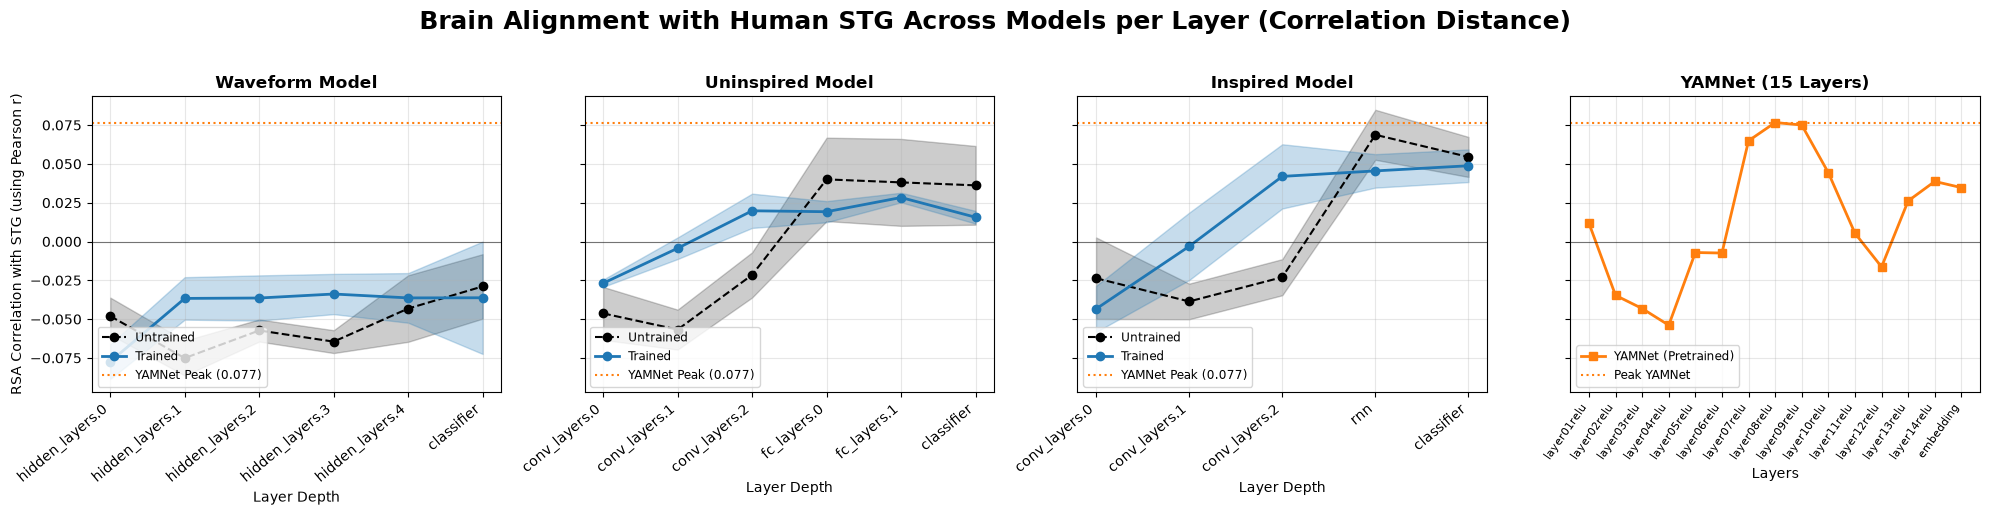

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
yamnet_peak = max(corr_yamnet_alignments.values())

for ax, model_name in zip(axes[:3], MODEL_CLASSES.keys()):
    layers = list(corr_untrained_alignments[model_name].keys())
    x = np.arange(len(layers))

    # Untrained mean & ci
    u_mean = np.array([corr_untrained_alignments[model_name][l]["mean"] for l in layers])
    u_ci = np.array([corr_untrained_alignments[model_name][l]["ci"] for l in layers])

    # Trained mean & ci
    t_mean = np.array([corr_trained_alignments[model_name][l]["mean"] for l in layers])
    t_ci = np.array([corr_trained_alignments[model_name][l]["ci"] for l in layers])

    # Plot Untrained
    ax.plot(x, u_mean, marker="o", linestyle="--", color="black", label="Untrained")
    # Add ci visualization
    ax.fill_between(x, u_mean - u_ci, u_mean + u_ci, color="black", alpha=0.2)

    # Plot Trained
    ax.plot(x, t_mean, marker="o", linewidth=2, color="tab:blue", label="Trained")
    # Add ci visualization
    ax.fill_between(x, t_mean - t_ci, t_mean + t_ci, color="tab:blue", alpha=0.25)

    # Reference lines (strongest yamnet)
    ax.axhline(yamnet_peak, color="tab:orange", linestyle=":", linewidth=1.5, label=f"YAMNet Peak ({yamnet_peak:.3f})")

    # Zero line
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)

    ax.set_title(f"{model_name.capitalize()} Model", fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(layers, rotation=40, ha="right")
    ax.set_xlabel("Layer Depth")
    ax.grid(alpha=0.3)
    ax.legend(loc="lower left", fontsize=8.5)

# Yamnet across all 15 layers
yam_layers = list(corr_yamnet_alignments.keys())
yam_scores = list(corr_yamnet_alignments.values())
x_yam = np.arange(len(yam_layers))

axes[3].plot(x_yam, yam_scores, marker="s", linewidth=2, color="tab:orange", label="YAMNet (Pretrained)")
axes[3].axhline(yamnet_peak, color="tab:orange", linestyle=":", linewidth=1.5, label="Peak YAMNet")
axes[3].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[3].set_title("YAMNet (15 Layers)", fontsize=12, fontweight="bold")
axes[3].set_xticks(x_yam)
axes[3].set_xticklabels(yam_layers, rotation=55, ha="right", fontsize=8)
axes[3].set_xlabel("Layers")
axes[3].grid(alpha=0.3)
axes[3].legend(loc="lower left", fontsize=8.5)
axes[0].set_ylabel("RSA Correlation with STG (using Pearson r)")

plt.suptitle("Brain Alignment with Human STG Across Models per Layer (Correlation Distance)", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3. Vizualization of

In [18]:
# Helper to find the best layer (optionally matching a prefix like 'conv_layers')
def find_peak_layer(alignments_dict: dict, prefix: str = "") -> str:
    matching_layers = [l for l in alignments_dict.keys() if l.startswith(prefix)]
    return max(matching_layers, key=lambda l: alignments_dict[l]["mean"])


# Helper to load activations from the single best run of a trained model
def get_best_run_activations(model_name: str, peak_layer: str) -> dict:
    # Score each run on its peak layer to find the best checkpoint
    runs_list = trained_rdms[model_name]
    run_scores = [compare_rdms(rdm_stg, run[peak_layer]) for run in runs_list]
    best_run_idx = int(np.argmax(run_scores))

    # Load that specific checkpoint file
    files = sorted(Path(CHECKPOINT_DIR).glob(f"{model_name}_run*_best.pt"))
    best_path = files[best_run_idx]

    model = MODEL_CLASSES[model_name](num_classes=NUM_CLASSES).to(device)
    state_dict = torch.load(best_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)

    return extract_activations(santoro_loader, model)


# Find peak layers for each model & YAMNet
best_yamnet_layer = max(yamnet_alignments, key=yamnet_alignments.get)

wave_peak_hidden = find_peak_layer(trained_alignments["waveform"], prefix="hidden_layers")
uninsp_peak_conv = find_peak_layer(trained_alignments["uninspired"], prefix="conv_layers")
uninsp_peak_fc   = find_peak_layer(trained_alignments["uninspired"], prefix="fc_layers")
insp_peak_conv   = find_peak_layer(trained_alignments["inspired"], prefix="conv_layers")

# Extract activations from the best run of each trained model
waveform_acts   = get_best_run_activations("waveform", wave_peak_hidden)
uninspired_acts = get_best_run_activations("uninspired", uninsp_peak_conv)
inspired_acts   = get_best_run_activations("inspired", insp_peak_conv)

# While not much meaningful, we will look at one untrained models for proper comparison
untrained_uninsp_peak = find_peak_layer(untrained_alignments["uninspired"], prefix="conv_layers")
untrained_uninsp_model = MODEL_CLASSES["uninspired"](num_classes=NUM_CLASSES).to(device)
untrained_uninsp_acts = extract_activations(santoro_loader, untrained_uninsp_model)
untrained_insp_peak = find_peak_layer(untrained_alignments["inspired"], prefix="conv_layers")
untrained_insp_model = MODEL_CLASSES["inspired"](num_classes=NUM_CLASSES).to(device)
untrained_insp_acts = extract_activations(santoro_loader, untrained_insp_model)

In [19]:
representations = {
    # Benchmarks & Waveform Baseline
    "Human STG Brain": santoro_dataset.brain_responses.numpy(),
    f"YAMNet Peak ({best_yamnet_layer})": yamnet_activations[best_yamnet_layer],
    f"Waveform Peak ({wave_peak_hidden})": waveform_acts[wave_peak_hidden].numpy(),
    "Waveform (classifier)": waveform_acts["classifier"].numpy(),

    # Uninspired Layers
    f"Uninspired Untrained ({untrained_uninsp_peak})": untrained_uninsp_acts[untrained_uninsp_peak].numpy(),
    f"Uninspired Peak ({uninsp_peak_conv})": uninspired_acts[uninsp_peak_conv].numpy(),
    f"Uninspired FC ({uninsp_peak_fc})": uninspired_acts[uninsp_peak_fc].numpy(),
    "Uninspired (classifier)": uninspired_acts["classifier"].numpy(),

    # Inspired Layers
    f"Inspired Untrained ({untrained_insp_peak})": untrained_insp_acts[untrained_insp_peak].numpy(),
    f"Inspired Peak ({insp_peak_conv})": inspired_acts[insp_peak_conv].numpy(),
    "Inspired (rnn)": inspired_acts["rnn"].numpy(),
    "Inspired (classifier)": inspired_acts["classifier"].numpy(),
}

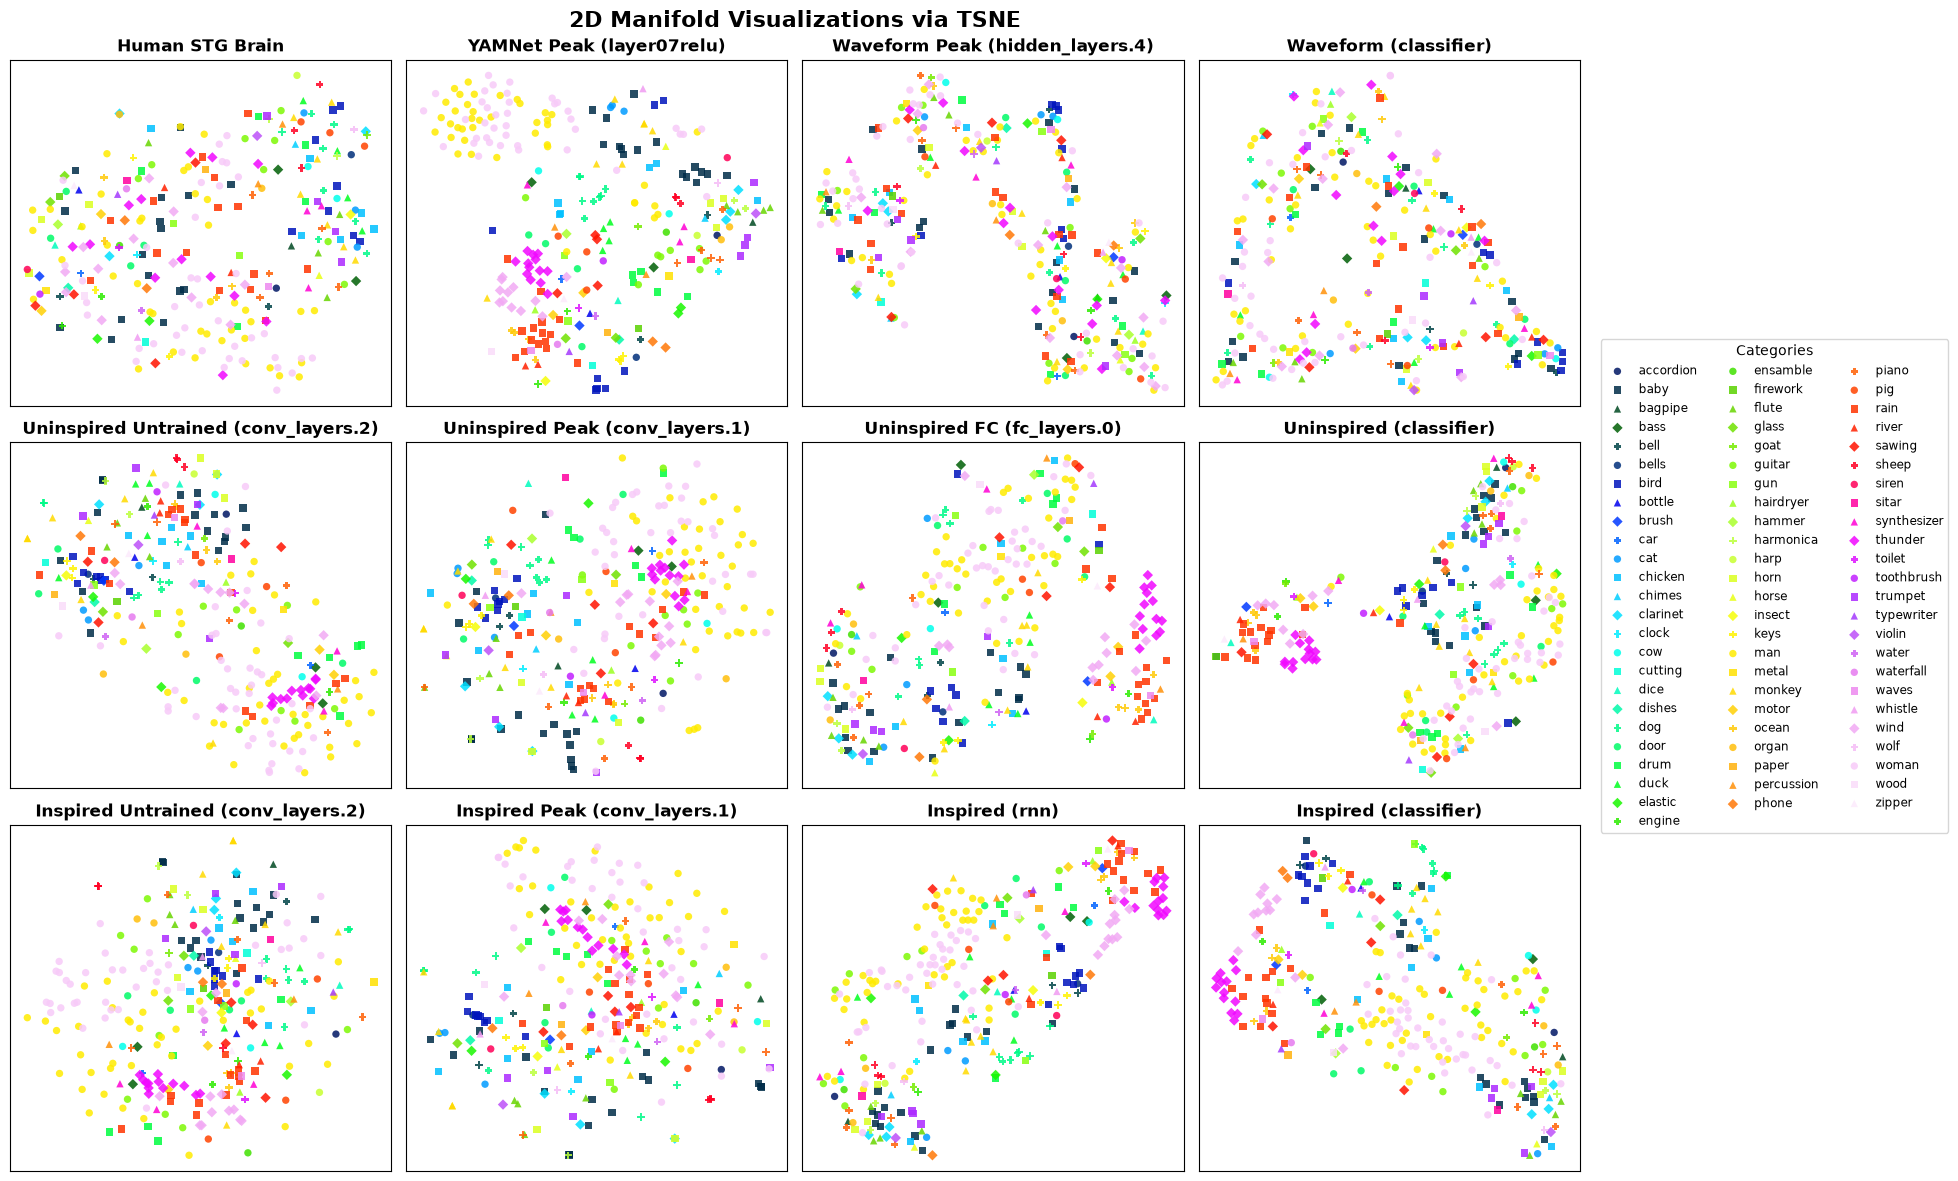

c:\Users\yanra\Documents\Maastricht\Bio Modelling\Modelling_of_Biological_Systems_Group_11\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\yanra\Documents\Maastricht\Bio Modelling\Modelling_of_Biological_Systems_Group_11\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\yanra\Documents\Maastricht\Bio Modelling\Modelling_of_Biological_Systems_Group_11\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\yanra\Documents\Maastricht\Bio Modelling\Modelling_of_Biological_Systems_Group_11\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\yanra\Documents\Maastricht\Bio 

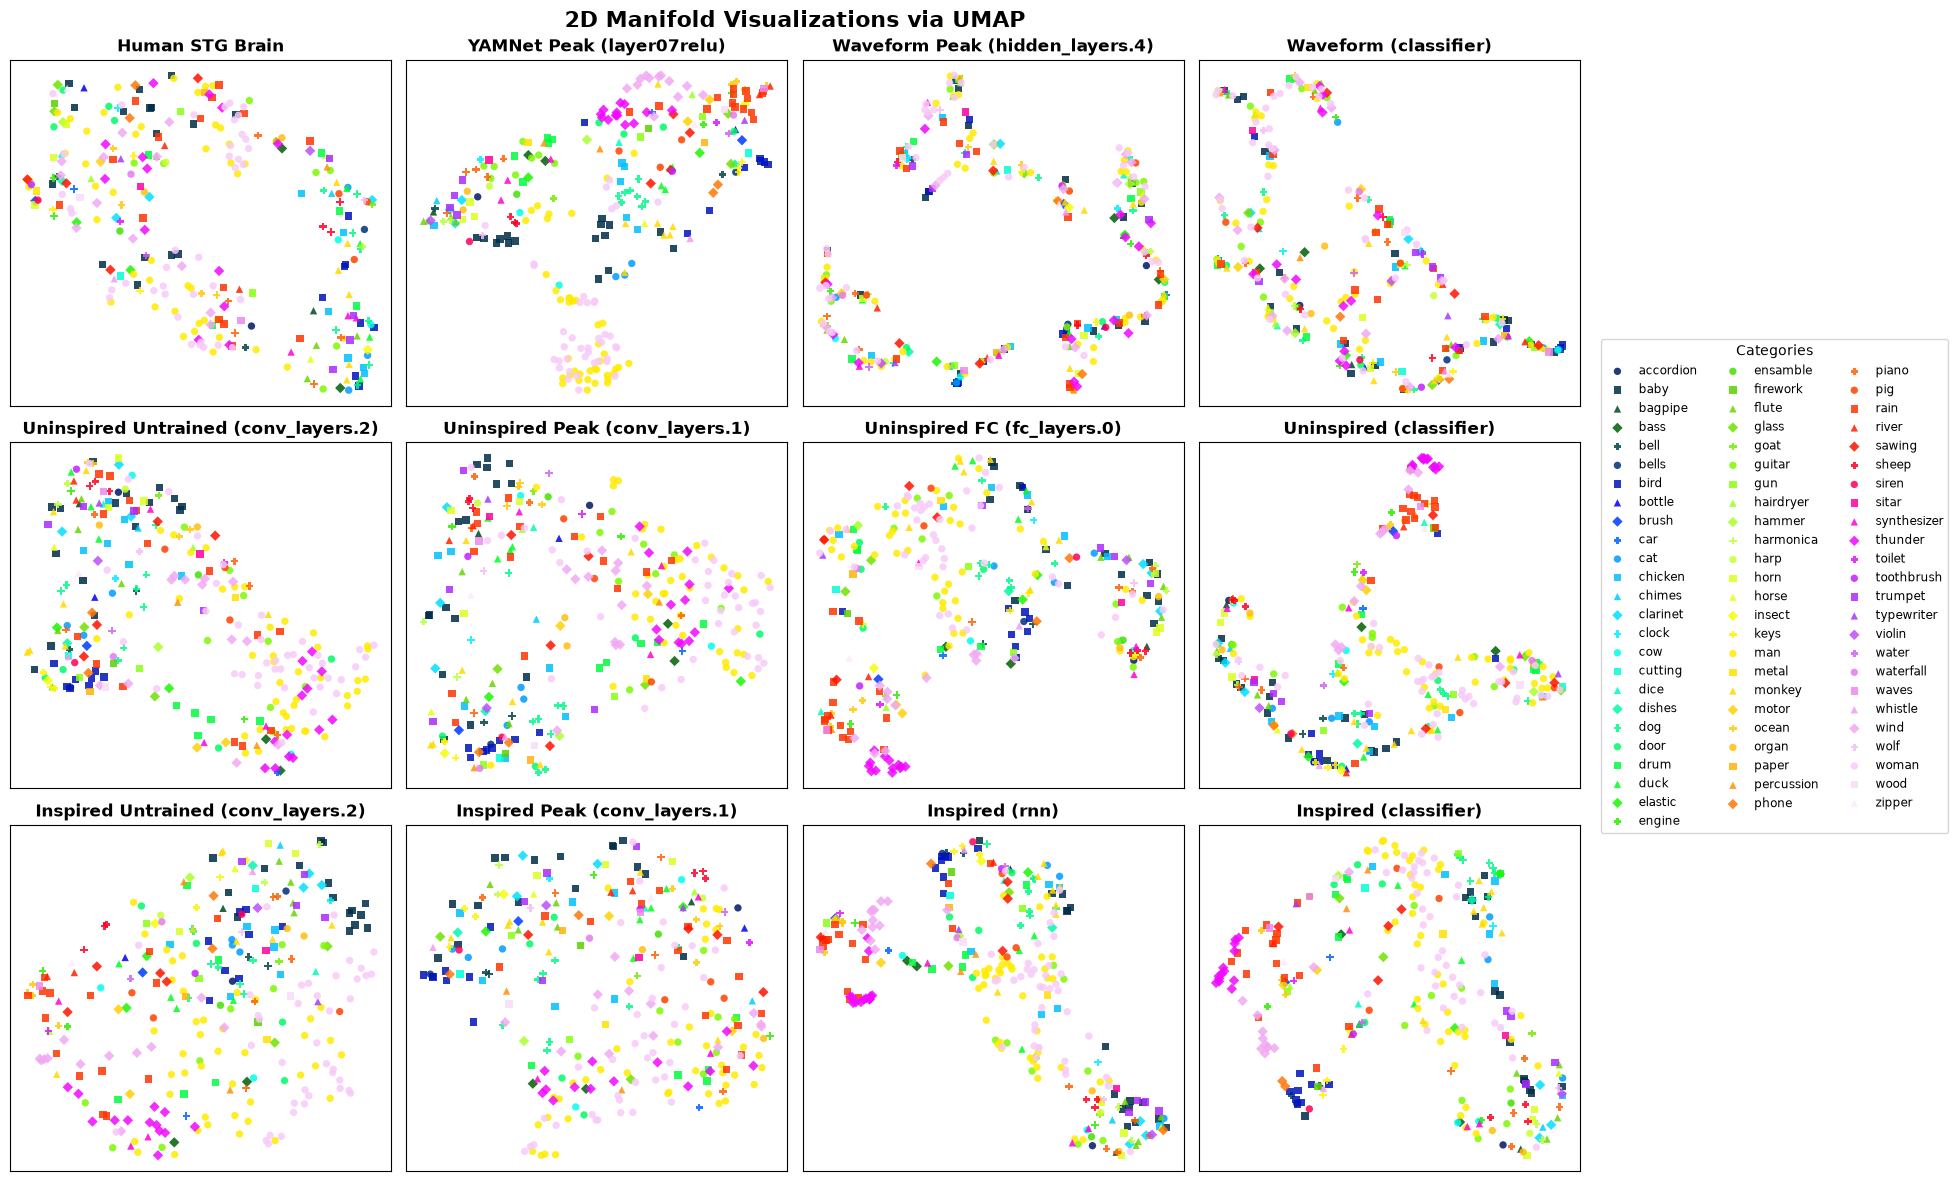

In [20]:
plot_embeddings(representations, np.array(santoro_dataset.categories), method="tsne")
plot_embeddings(representations, np.array(santoro_dataset.categories), method="umap")

As a respectable member of the t-SNE hater club, I decided to give one more chance and set almost random hyperparameters for both t-SNE and UMAP to see how easy each method to use. We know that major focus of t-SNE is to preserve local pairwise neighborhoods while UMAP balances local neighborhood structure with global manifold topology. So let's have a first look:
- While both methods for models like Inspired Untrained or Inspired peak produce not very clustered images, still UMAP has better geometry visualization and separation between the groups. Therefore, I'm continuing the membership at the t-SNE hater club...
- **TODO:** actual analysis of plots, even though they are messy. Majorpriority is to explore UMAP plots.